# Fine-Tuning CLIP for Image Classification

In this notebook, we look at how to actually **fine-tune** a pretrained CLIP model for image classification -- as opposed to the **zero-shot** use of CLIP shown in the earlier [CLIP contrastive learning notebook](01_clip_contrastive_learning_zero_shot.ipynb) (Part 3 there), where the pretrained weights were only ever used for *inference*, never updated.

## What's different from "zero-shot CLIP" (Part 3 of the earlier lab)?

| | Zero-shot CLIP (earlier lab, Part 3) | This notebook |
|---|---|---|
| Are CLIP's weights ever updated? | **No** -- `model.eval()`, no `backward()`, no optimizer | **Yes** -- at least part of the model is trained |
| What decides the predicted class? | Similarity to text prompts like `"a photo of a {class}"` | A trained classifier head (and, in Part B below, updated CLIP features) |
| Needs labeled training data? | No | Yes |
| Typical use case | Quick classification with no training at all | Squeezing out extra accuracy on a *specific* dataset you do have labels for |

This notebook implements **two** variants, so you can compare them directly:
- **Part A -- Linear probing**: freeze the entire CLIP model, and train only a new linear classifier on top of its (frozen) image features. This is what the original version of this notebook implemented, even though it called it "fine-tuning" -- a common mix-up worth being precise about.
- **Part B -- Real fine-tuning**: unfreeze the last few layers of CLIP's vision encoder as well, so the pretrained features themselves get adapted to the new dataset, not just the final classifier.

## What else changed from the original version of this notebook

- **Library**: the original used the standalone `openai-clip` package (`import clip`, `clip.load(...)`). We use Hugging Face `transformers` (`CLIPModel`, `CLIPProcessor`) instead -- the same library as the earlier zero-shot lab, so there's only one CLIP dependency to manage across both notebooks, and no separate installation quirks to debug.
- **Dataset**: the original used `ceyda/fashion-products-small`, a community dataset of real product photos downloaded through Hugging Face `datasets` -- slow to download and a dependency that can break or disappear. We use **FashionMNIST** instead (via `torchvision`, ~30MB, extremely reliable to download), for the same reason we switched to it in the earlier lab: lighter, faster, and its class names are just as easy to turn into classification labels.


# Learning Objectives

By the end of this notebook, you should be able to:

- explain the difference between zero-shot use, linear probing, and fine-tuning of a pretrained model
- wrap a pretrained CLIP model with a new classification head in PyTorch
- selectively freeze and unfreeze parts of a pretrained model (`clip_model.vision_model.encoder.layers`)
- train and compare a linear-probed CLIP against a partially fine-tuned CLIP on the same dataset
- implement a CLIP-based retrieval system (text-to-image and image-to-text) as an exercise

## Step 1 — Install and Import Libraries

In [ ]:
%pip install -q -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 94.0 MB/s eta 0:00:00


In [ ]:
import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets

from transformers import CLIPModel, CLIPProcessor
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(42)
np.random.seed(42)

PyTorch version: 2.11.0+cu128
Using device: cuda


## Step 2 — Load the Dataset (FashionMNIST)

FashionMNIST is grayscale and `28x28`; CLIP expects RGB images at `224x224`. Rather than writing that preprocessing by hand, we let `CLIPProcessor` handle it -- it already knows exactly what resizing and normalization the pretrained model expects.

In [ ]:
fashion_train_raw = datasets.FashionMNIST(root="./data", train=True, download=True)
fashion_test_raw = datasets.FashionMNIST(root="./data", train=False, download=True)

class_names = fashion_train_raw.classes
print("Classes:", class_names)
print("Train size:", len(fashion_train_raw), " Test size:", len(fashion_test_raw))

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 178kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.12MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.7MB/s]

Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Train size: 60000  Test size: 10000


## Step 3 — Load the Pretrained CLIP Model

In [ ]:
clip_model_id = "openai/clip-vit-base-patch32"

processor = CLIPProcessor.from_pretrained(clip_model_id)
clip_model = CLIPModel.from_pretrained(clip_model_id).to(device)

print("Loaded:", clip_model_id)
print("Vision encoder blocks:", len(clip_model.vision_model.encoder.layers))
print("Projection dim:", clip_model.config.projection_dim)

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loaded: openai/clip-vit-base-patch32
Vision encoder blocks: 12
Projection dim: 512


### A note on `get_text_features` / `get_image_features` across `transformers` versions

Depending on which version of `transformers` you have installed, `CLIPModel.get_text_features(...)` and `get_image_features(...)` return **either** a plain tensor of embeddings directly, **or** a `BaseModelOutputWithPooling` object whose `.pooler_output` attribute holds those embeddings instead (a real API change introduced in some releases). Code written against one version silently breaks on the other -- not with a crash necessarily, but with wrong results if you don't handle it. We use a small helper everywhere below so this notebook works either way.

In [ ]:
def extract_features(output):
    """Works whether get_text_features/get_image_features returns a plain tensor
    (older transformers) or a BaseModelOutputWithPooling object (newer transformers,
    where the embeddings live in .pooler_output)."""
    return output.pooler_output if hasattr(output, "pooler_output") else output

## Step 4 — Baseline: Zero-Shot Performance (No Training At All)

Before fine-tuning anything, let's see how the frozen, pretrained CLIP does on this dataset purely zero-shot -- exactly like the earlier lab's Part 3, just on FashionMNIST this time. This gives us a baseline to know whether fine-tuning is actually helping.

In [ ]:
def zero_shot_predict(images_pil, class_names, device, batch_size=64):
    prompts = [f"a photo of a {name}" for name in class_names]
    with torch.no_grad():
        text_inputs = processor(text=prompts, return_tensors="pt", padding=True).to(device)
        text_embeds = extract_features(clip_model.get_text_features(**text_inputs))
        text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)

    all_preds = []
    for i in range(0, len(images_pil), batch_size):
        batch = images_pil[i:i + batch_size]
        with torch.no_grad():
            pixel_values = processor(images=batch, return_tensors="pt")["pixel_values"].to(device)
            image_embeds = extract_features(clip_model.get_image_features(pixel_values=pixel_values))
            image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
            similarity = image_embeds @ text_embeds.t()
            all_preds.append(torch.argmax(similarity, dim=1).cpu())
    return torch.cat(all_preds).numpy()


# Evaluate on a subset of the test set for speed (zero-shot needs no training, but a full
# pass over 10,000 images just to get a baseline number would be slow for a quick check)
n_eval = 500
eval_images = [fashion_test_raw[i][0].convert("RGB") for i in range(n_eval)]
eval_labels = np.array([fashion_test_raw[i][1] for i in range(n_eval)])

zero_shot_preds = zero_shot_predict(eval_images, class_names, device)
zero_shot_acc = (zero_shot_preds == eval_labels).mean()
print(f"Zero-shot accuracy on {n_eval} FashionMNIST test images: {zero_shot_acc:.4f}")

Zero-shot accuracy on 500 FashionMNIST test images: 0.6160


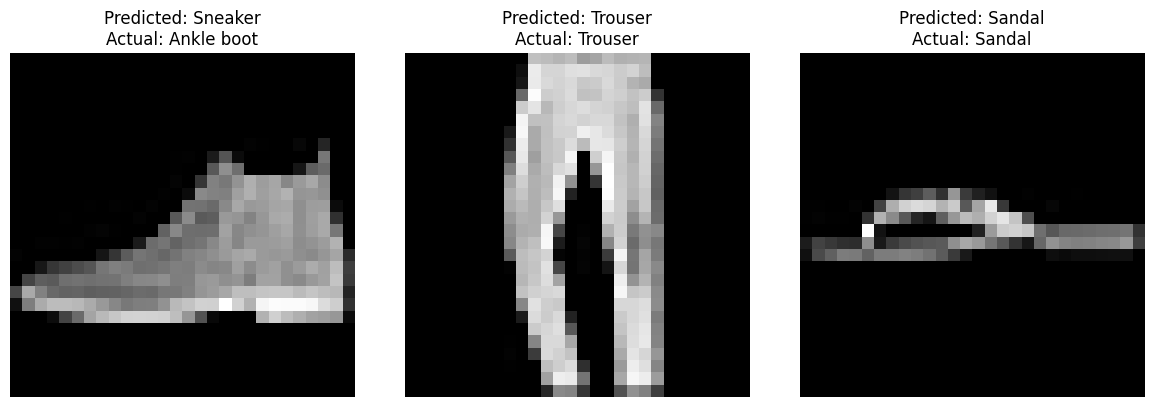

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, idx in enumerate([0, 5, 8]):
    axes[i].imshow(eval_images[idx])
    axes[i].set_title(f"Predicted: {class_names[zero_shot_preds[idx]]}\nActual: {class_names[eval_labels[idx]]}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

## Step 5 — Prepare the Dataset for Training

In [ ]:
train_size = int(0.8 * len(fashion_train_raw))
val_size = len(fashion_train_raw) - train_size
train_subset, val_subset = random_split(fashion_train_raw, [train_size, val_size],
                                         generator=torch.Generator().manual_seed(42))

print("Train:", len(train_subset), " Val:", len(val_subset))

Train: 48000  Val: 12000


In [ ]:
class FashionCLIPDataset(Dataset):
    """Wraps a FashionMNIST split, returning RGB PIL images (CLIP's preprocessing
    happens later, in the collate function, using CLIPProcessor)."""
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, label = self.base_dataset[idx]
        return image.convert("RGB"), label


def make_collate_fn(processor):
    def collate_fn(batch):
        images, labels = zip(*batch)
        pixel_values = processor(images=list(images), return_tensors="pt")["pixel_values"]
        labels = torch.tensor(labels, dtype=torch.long)
        return pixel_values, labels
    return collate_fn


collate_fn = make_collate_fn(processor)

batch_size = 32
train_loader = DataLoader(FashionCLIPDataset(train_subset), batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(FashionCLIPDataset(val_subset), batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(FashionCLIPDataset(fashion_test_raw), batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

## Step 6 — The Classifier Wrapper

A single class handles **both** Part A (linear probing) and Part B (fine-tuning): the difference between them is entirely in *which parameters are frozen*, set up outside this class, not in the class itself.

In [ ]:
class CLIPClassifier(nn.Module):
    def __init__(self, clip_model, num_classes):
        super().__init__()
        self.clip_model = clip_model
        self.classifier = nn.Linear(clip_model.config.projection_dim, num_classes)

    def forward(self, pixel_values):
        # Whether gradients actually flow through clip_model depends on which of its
        # parameters have requires_grad=True -- set up by the freeze/unfreeze code below,
        # not by this forward method.
        features = extract_features(self.clip_model.get_image_features(pixel_values=pixel_values))
        return self.classifier(features.float())

## Step 7 — Shared Training Utilities

In [ ]:
def evaluate_classifier(model, data_loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for pixel_values, labels in data_loader:
            pixel_values, labels = pixel_values.to(device), labels.to(device)
            logits = model(pixel_values)
            loss = criterion(logits, labels)
            total_loss += loss.item() * pixel_values.size(0)
            correct += (torch.argmax(logits, dim=1) == labels).sum().item()
            total += pixel_values.size(0)
    return total_loss / total, correct / total


def train_with_early_stopping(model, train_loader, val_loader, device, epochs=5, patience=3, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(trainable_params, lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)

    history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}
    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for pixel_values, labels in train_loader:
            pixel_values, labels = pixel_values.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = model(pixel_values)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * pixel_values.size(0)
            correct += (torch.argmax(logits, dim=1) == labels).sum().item()
            total += pixel_values.size(0)

        train_loss, train_acc = running_loss / total, correct / total
        val_loss, val_acc = evaluate_classifier(model, val_loader, criterion, device)

        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} "
              f"- val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping triggered after epoch {epoch+1}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

## Part A — Linear Probing (Entire CLIP Frozen)

Every CLIP parameter is frozen; only the new `classifier` layer is trained. This is what the original notebook did, correctly labeled this time.

In [ ]:
import copy as _copy  # local alias avoids shadowing issues if this cell is re-run

clip_model_a = CLIPModel.from_pretrained(clip_model_id).to(device)
for param in clip_model_a.parameters():
    param.requires_grad = False

model_a = CLIPClassifier(clip_model_a, num_classes=len(class_names)).to(device)

trainable_a = sum(p.numel() for p in model_a.parameters() if p.requires_grad)
total_a = sum(p.numel() for p in model_a.parameters())
print(f"Part A (linear probe) -- trainable parameters: {trainable_a:,} / {total_a:,}")

print("\n=== Training Part A: linear probing ===")
start_time = time.time()
history_a = train_with_early_stopping(model_a, train_loader, val_loader, device, epochs=5, patience=3, lr=1e-3)
time_a = time.time() - start_time
print(f"Part A training time: {time_a:.2f} seconds")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Part A (linear probe) -- trainable parameters: 5,130 / 151,282,443

=== Training Part A: linear probing ===
Epoch 1/5 - loss: 0.5411 - accuracy: 0.8342 - val_loss: 0.3856 - val_accuracy: 0.8622
Epoch 2/5 - loss: 0.3530 - accuracy: 0.8741 - val_loss: 0.3482 - val_accuracy: 0.8736
Epoch 3/5 - loss: 0.3254 - accuracy: 0.8821 - val_loss: 0.3345 - val_accuracy: 0.8781
Epoch 4/5 - loss: 0.3098 - accuracy: 0.8878 - val_loss: 0.3227 - val_accuracy: 0.8837
Epoch 5/5 - loss: 0.2996 - accuracy: 0.8913 - val_loss: 0.3150 - val_accuracy: 0.8867
Part A training time: 1100.22 seconds


## Part B — Real Fine-Tuning (Unfreeze the Last Vision Encoder Blocks)

We unfreeze the last 2 of CLIP's 12 vision-encoder blocks (plus the projection layer that follows them), so the pretrained visual features themselves get to adapt to FashionMNIST, not just the classifier reading them. We use a **much smaller learning rate** than Part A, so we nudge the pretrained features rather than overwrite what they already learned from millions of images.

In [ ]:
clip_model_b = CLIPModel.from_pretrained(clip_model_id).to(device)

for param in clip_model_b.parameters():
    param.requires_grad = False
for block in clip_model_b.vision_model.encoder.layers[-2:]:
    for param in block.parameters():
        param.requires_grad = True
for param in clip_model_b.visual_projection.parameters():
    param.requires_grad = True

model_b = CLIPClassifier(clip_model_b, num_classes=len(class_names)).to(device)

trainable_b = sum(p.numel() for p in model_b.parameters() if p.requires_grad)
total_b = sum(p.numel() for p in model_b.parameters())
print(f"Part B (fine-tuning) -- trainable parameters: {trainable_b:,} / {total_b:,}")

print("\n=== Training Part B: fine-tuning the last vision blocks ===")
start_time = time.time()
history_b = train_with_early_stopping(model_b, train_loader, val_loader, device, epochs=5, patience=3, lr=1e-5)
time_b = time.time() - start_time
print(f"Part B training time: {time_b:.2f} seconds")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Part B (fine-tuning) -- trainable parameters: 14,574,090 / 151,282,443

=== Training Part B: fine-tuning the last vision blocks ===
Epoch 1/5 - loss: 0.3705 - accuracy: 0.8766 - val_loss: 0.2631 - val_accuracy: 0.9058
Epoch 2/5 - loss: 0.2155 - accuracy: 0.9221 - val_loss: 0.2267 - val_accuracy: 0.9153
Epoch 3/5 - loss: 0.1698 - accuracy: 0.9396 - val_loss: 0.2216 - val_accuracy: 0.9203
Epoch 4/5 - loss: 0.1286 - accuracy: 0.9542 - val_loss: 0.2108 - val_accuracy: 0.9266
Epoch 5/5 - loss: 0.0895 - accuracy: 0.9689 - val_loss: 0.2362 - val_accuracy: 0.9210
Part B training time: 1339.35 seconds


## Step 8 — Compare Zero-Shot, Linear Probing, and Fine-Tuning

In [ ]:
criterion = nn.CrossEntropyLoss()
test_loss_a, test_acc_a = evaluate_classifier(model_a, test_loader, criterion, device)
test_loss_b, test_acc_b = evaluate_classifier(model_b, test_loader, criterion, device)

import pandas as pd

comparison = pd.DataFrame([
    {"Approach": "Zero-shot (no training)", "Trainable params": 0, "Test accuracy": zero_shot_acc},
    {"Approach": "Part A: Linear probing", "Trainable params": trainable_a, "Test accuracy": test_acc_a},
    {"Approach": "Part B: Fine-tuning (last 2 blocks)", "Trainable params": trainable_b, "Test accuracy": test_acc_b},
])
comparison

,Approach,Trainable params,Test accuracy
0,Zero-shot (no training),0,0.6160
1,Part A: Linear probing,5130,0.8864
2,Part B: Fine-tuning (last 2 blocks),14574090,0.9246


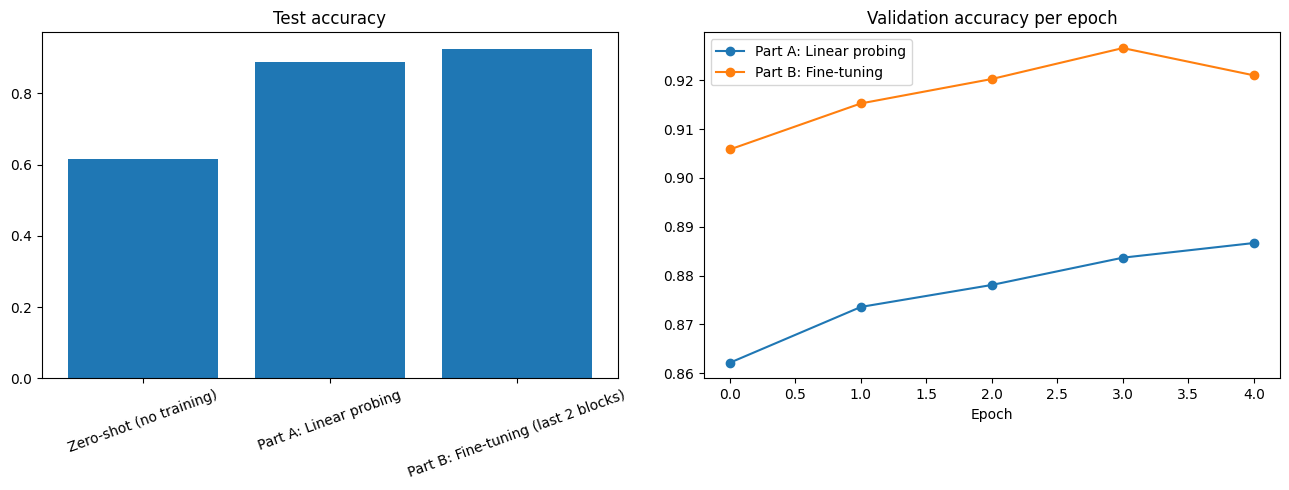

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(comparison["Approach"], comparison["Test accuracy"])
axes[0].set_title("Test accuracy")
axes[0].tick_params(axis="x", rotation=20)

axes[1].plot(history_a["val_accuracy"], label="Part A: Linear probing", marker="o")
axes[1].plot(history_b["val_accuracy"], label="Part B: Fine-tuning", marker="o")
axes[1].set_title("Validation accuracy per epoch")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

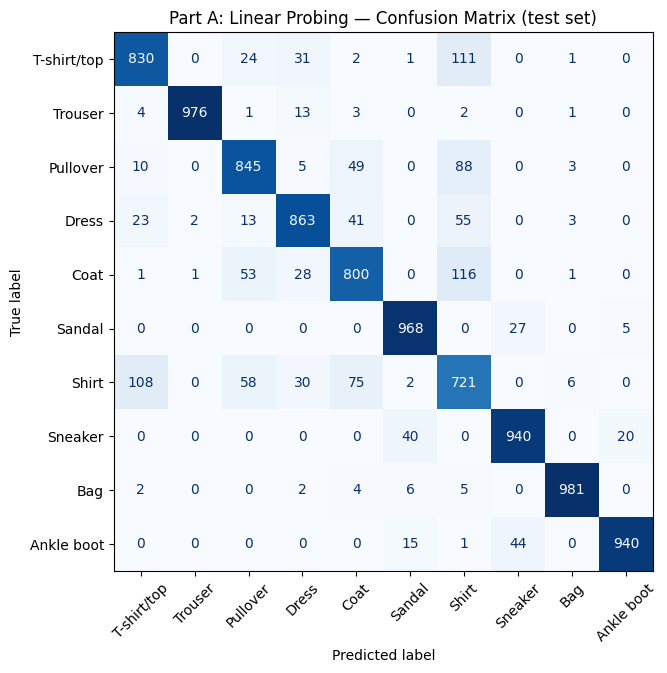

              precision    recall  f1-score   support

 T-shirt/top       0.85      0.83      0.84      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.85      0.84      0.85      1000
       Dress       0.89      0.86      0.88      1000
        Coat       0.82      0.80      0.81      1000
      Sandal       0.94      0.97      0.95      1000
       Shirt       0.66      0.72      0.69      1000
     Sneaker       0.93      0.94      0.93      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.97      0.94      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



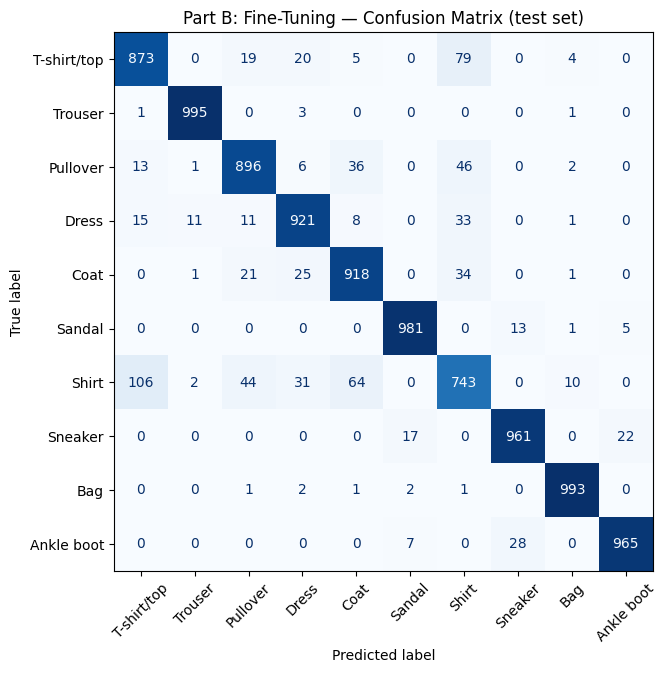

              precision    recall  f1-score   support

 T-shirt/top       0.87      0.87      0.87      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.90      0.90      0.90      1000
       Dress       0.91      0.92      0.92      1000
        Coat       0.89      0.92      0.90      1000
      Sandal       0.97      0.98      0.98      1000
       Shirt       0.79      0.74      0.77      1000
     Sneaker       0.96      0.96      0.96      1000
         Bag       0.98      0.99      0.99      1000
  Ankle boot       0.97      0.96      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



In [ ]:
def show_confusion_matrix(model, name):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for pixel_values, labels in test_loader:
            pixel_values = pixel_values.to(device)
            preds = torch.argmax(model(pixel_values), dim=1).cpu().numpy()
            all_preds.append(preds)
            all_true.append(labels.numpy())
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_true)

    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    fig, ax = plt.subplots(figsize=(7, 7))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
    plt.title(f"{name} — Confusion Matrix (test set)")
    plt.show()
    print(classification_report(y_true, y_pred, target_names=class_names))

show_confusion_matrix(model_a, "Part A: Linear Probing")
show_confusion_matrix(model_b, "Part B: Fine-Tuning")

## Step 9 — Visualize Predictions

Same three example images the original notebook checked, now compared across all three approaches (fixed: no more loading a checkpoint file that was never saved -- we just reuse the trained models already in memory).

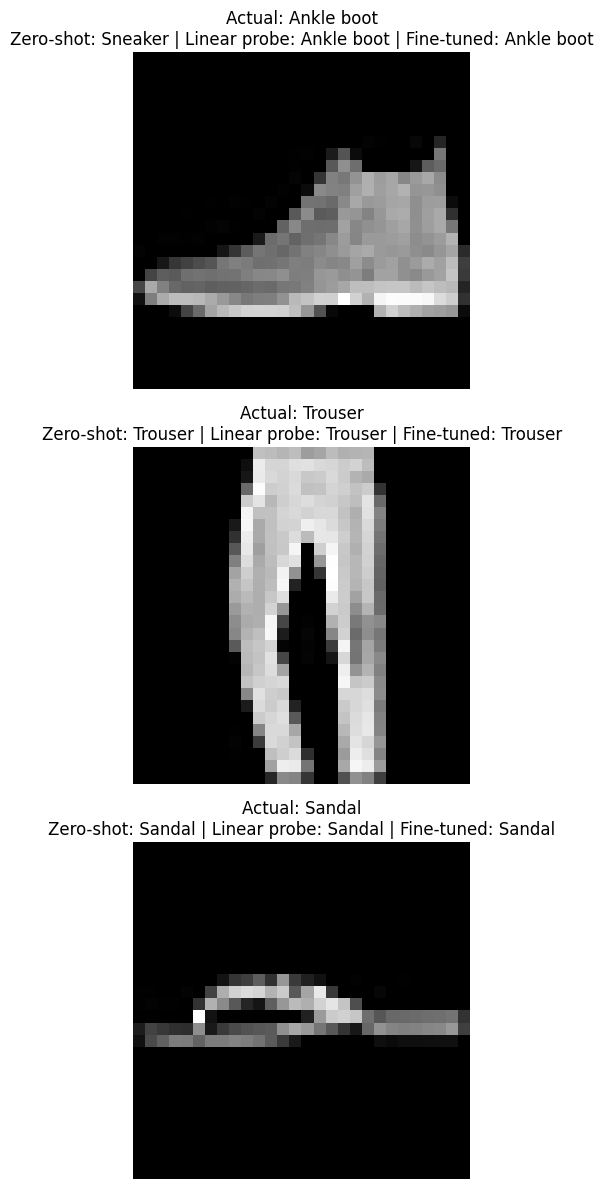

In [ ]:
def predict_single(model, pil_image, device):
    model.eval()
    with torch.no_grad():
        pixel_values = processor(images=[pil_image], return_tensors="pt")["pixel_values"].to(device)
        logits = model(pixel_values)
        return torch.argmax(logits, dim=1).item()


indices = [0, 5, 8]
fig, axes = plt.subplots(len(indices), 1, figsize=(6, 4 * len(indices)))

for row, idx in enumerate(indices):
    image, true_label = fashion_test_raw[idx]
    image_rgb = image.convert("RGB")

    pred_zero_shot = class_names[zero_shot_predict([image_rgb], class_names, device)[0]]
    pred_a = class_names[predict_single(model_a, image_rgb, device)]
    pred_b = class_names[predict_single(model_b, image_rgb, device)]

    axes[row].imshow(image_rgb)
    axes[row].set_title(
        f"Actual: {class_names[true_label]}\n"
        f"Zero-shot: {pred_zero_shot} | Linear probe: {pred_a} | Fine-tuned: {pred_b}"
    )
    axes[row].axis("off")

plt.tight_layout()
plt.show()

## Final Questions

1. Look at the trainable-parameter counts for Parts A and B. Why is Part B's count so much smaller than CLIP's total parameter count, even though we call it "fine-tuning"?
2. Why does Part B use a much smaller learning rate (`1e-5`) than Part A (`1e-3`)? What would likely happen to the pretrained features if we used `1e-3` for Part B too?
3. Compare zero-shot, linear probing, and fine-tuning accuracy. Does fine-tuning actually beat linear probing here? If the gap is small, what does that suggest about how much useful, general-purpose visual information CLIP's frozen features already contain?
4. If you had a much smaller labeled training set (say, 50 images per class instead of thousands), would you expect linear probing or fine-tuning to be more robust? Why?
5. What would happen if you unfroze **all 12** vision encoder blocks instead of just the last 2, using the same small learning rate? What about using a large dataset vs. a small one for that experiment?
6. Look at the confusion matrices for linear probing vs. fine-tuning. Are the same class pairs confused in both, or different ones?

# Answer

1. There are far fewer parameters to train because the first 10 layers of the original CLIP are frozen; only the last 2 layers are trained.

2. Fine-tuning should focus on precise adjustments, since the weights are already trained. To avoid catastrophic forgetting, we use a small learning rate.

3. The gap with zero-shot is huge, but not so much between linear probing and fine-tuning. This shows that most of the information learned in the 2 fine-tuned layers is already contained in CLIP's last layers, just mixed in with other learned features: the final layer of the linear probe can recover it.

4. With 50 classes, the dataset would be far too small and would inevitably cause overfitting, leading to disastrous fine-tuning results.

5. With all layers unfrozen and a large dataset, we could get interesting or even better results, since the model would be fully adapted to our task; with a small dataset, however, we would most likely overfit.

6. Yes, they are always the same ones, which highlights how similar these classes are. However, the results on them are better with fine-tuning, showing that the representation of these images can be improved.